In [2]:
# conda activate chronocell

import sys
import glob
import pickle
import numpy as np
import pandas as pd
from functools import reduce
import matplotlib.pyplot as plt

sys.path.append("/mnt/lareaulab/reliscu/programs/FGP_2024")
sys.path.append("code")
sys.path.append("/mnt/lareaulab/reliscu/projects/Chronocell/analyses/simulations/code")

import Chronocell
from impute_protein import *
from protein_from_RNA import *

In [2]:
prefix = "janssens_2025_preprint_Chronocell_eLNPs_var>1.5_204_fitted_genes"

In [3]:
with open(f"data/{prefix}_traj_WS.pkl", "rb") as f:
    traj = pickle.load(f)

# Names of genes in Chronocell object
genes = pd.read_csv(f"data/{prefix}.csv")

In [4]:
sampleinfo = pd.read_csv(f"data/{prefix}_sampleinfo_barcode_level.csv")

# orig_corr = pd.read_csv("data/janssens_2025_preprint_author_counts_eLNP_RNA_vs_ADT_corrs.csv")

expr_ADT_imputed = pd.read_csv(f"data/{prefix}_RNA_history_imputed_protein.csv")
expr_ADT = pd.read_csv("data/janssens_2025_preprint_author_ADT_counts_eLNP.csv", index_col=0)
expr_RNA = pd.read_csv("data/janssens_2025_preprint_author_RNA_counts_eLNP.csv", index_col=0)

In [5]:
# Subset to genes of interest

# orig_corr = orig_corr.loc[orig_corr['Gene'].isin(expr_ADT_imputed.columns)]

In [6]:
t = traj.t
Q = traj.Q[:, 0, :]

In [7]:
# Make sure order of cells matches

expr_ADT_imputed.index = sampleinfo['Cell_ID']

expr_ADT.index = expr_ADT.index.str.replace("-1", "", regex=False)
expr_ADT.index = expr_ADT.index.str.replace("_", "-", regex=False)

expr_RNA.index = expr_RNA.index.str.replace("-1", "", regex=False)
expr_RNA.index = expr_RNA.index.str.replace("_", "-", regex=False)

In [8]:
expr_RNA = expr_RNA.loc[expr_ADT_imputed.index]
expr_ADT = expr_ADT.loc[expr_ADT_imputed.index]

In [9]:
np.all(expr_ADT_imputed.index == expr_ADT.index)

np.True_

In [10]:
np.all(expr_ADT_imputed.index == expr_RNA.index)

np.True_

In [11]:
# Order cells by their inferred place in time

In [12]:
Q_max_idx = np.argmax(Q, axis=1)

cell_order_idx = np.argsort(Q_max_idx)
cell_index = expr_ADT.index[cell_order_idx]

expr_ADT_ordered = expr_ADT.loc[cell_index]
expr_RNA_ordered = expr_RNA.loc[cell_index]
expr_ADT_imputed_ordered = expr_ADT_imputed.loc[cell_index]

In [13]:
# Time point per cell for plotting

t_per_cell = t[np.sort(Q_max_idx)]

In [14]:
prot = "CD63"
gene = "Cd63"

In [15]:
# Load imputed RNA for working gene

file_path = f"data/RNA_history_per_gene/{prefix}_{gene}_S_RNA_history.pkl"

with open(file_path, "rb") as f:
    X_bw = pickle.load(f)
    
X_bw_ordered = X_bw[cell_order_idx, :]
Q_max_idx_ordered = Q_max_idx[cell_order_idx]

In [16]:
# Subset to end cell to get whole trajectory
end_cells_idx = np.where(Q_max_idx_ordered == 99)[0]
end_cells_idx

array([20199, 20200, 20201, ..., 21322, 21323, 21324])

In [17]:
# Plot imputed RNA and protein for various cells

Text(0.5, 1.0, 'Imputed Cd63 RNA for cell 21241')

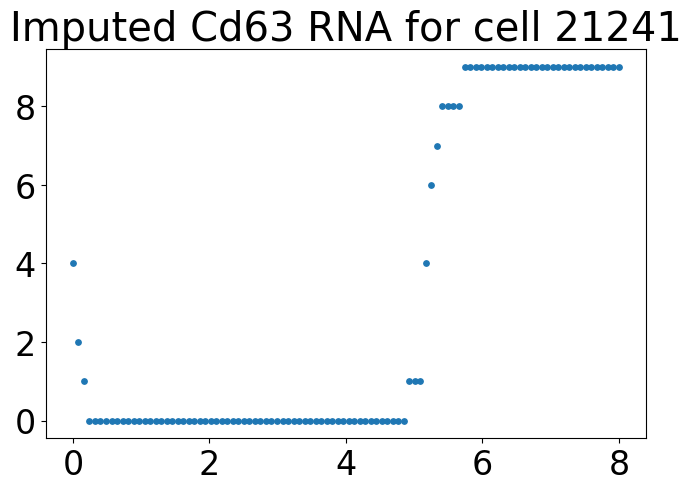

In [ ]:
idx = -1

plt.scatter(
    t,
    X_bw_ordered[idx, :],
    s=15
)
# plt.scatter(
#     t[Q_max_idx_ordered[idx]],
#     expr_ADT_imputed_ordered.iloc[idx].loc[gene]
# )
plt.title(f"Imputed {gene} RNA for cell {cell_order_idx[idx]}")

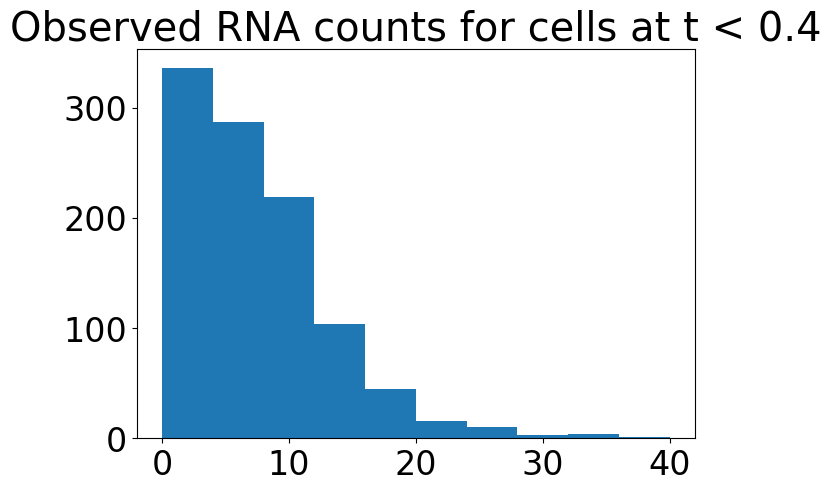

In [21]:
plt.hist(expr_RNA_ordered[gene][t_per_cell < 0.4]);
plt.title("Observed RNA counts for cells at t < 0.4");

In [23]:
pd.Categorical(sampleinfo["newClustersTmp"])

['Immature cDC1s', 'Late mature cDC1s', 'Immature cDC1s', 'Immature cDC1s', 'Early mature cDC1s', ..., 'Proliferating cDC1s', 'Late mature cDC1s', 'Late mature cDC1s', 'Late mature cDC1s', 'Late mature cDC1s']
Length: 21325
Categories (4, object): ['Early mature cDC1s', 'Immature cDC1s', 'Late mature cDC1s', 'Proliferating cDC1s']

In [24]:
new_order = ["Proliferating cDC1s", "Immature cDC1s", "Early mature cDC1s", "Late mature cDC1s"]

sampleinfo["newClustersTmp"] = pd.Categorical(
    sampleinfo["newClustersTmp"],
    categories=new_order,
    ordered=True
)

/tmp/ipykernel_2832107/3359226301.py:25: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/tmp/ipykernel_2832107/3359226301.py:25: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


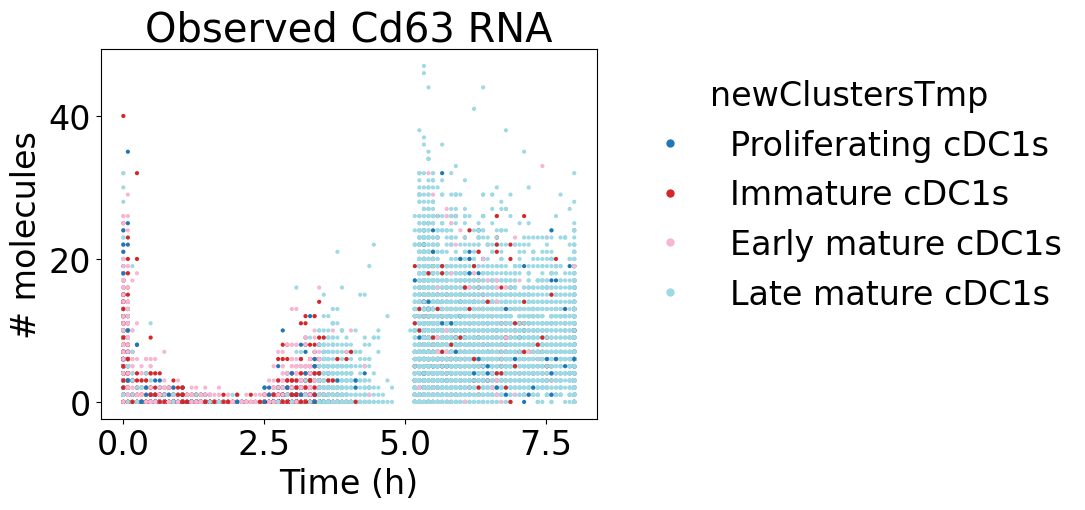

/tmp/ipykernel_2832107/3359226301.py:33: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


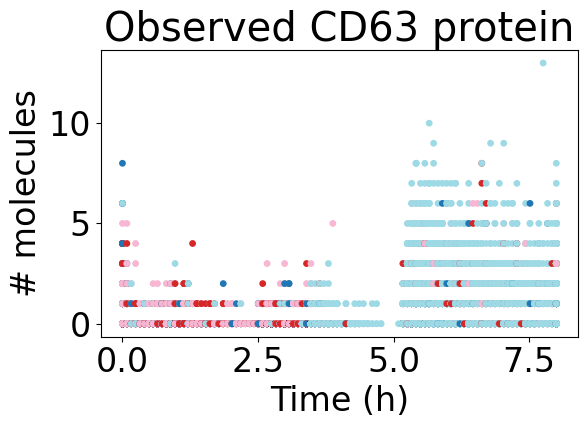

In [65]:
from matplotlib.lines import Line2D

clusters = pd.Categorical(sampleinfo["newClustersTmp"])
codes = clusters.codes
labels = clusters.categories
cmap = plt.get_cmap("tab20", len(labels))  # discrete colors

# --- RNA ---
plt.scatter(t_per_cell, expr_RNA_ordered[gene], c=codes, cmap=cmap, s=4)

handles = [
    Line2D([0], [0], marker='o', linestyle='None',
           markerfacecolor=cmap(i), markeredgecolor='none',
           markersize=6, label=str(lbl))
    for i, lbl in enumerate(labels)
]
plt.legend(handles=handles, title="newClustersTmp",
           bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)

plt.title(f"Observed {gene} RNA")
plt.xlabel("Time (h)")
plt.ylabel("# molecules")
plt.tight_layout()
plt.show()

# --- Protein ---
plt.scatter(t_per_cell, expr_ADT_ordered[prot], c=codes, cmap=cmap, s=15)
plt.title(f"Observed {prot} protein")
plt.xlabel("Time (h)")
plt.ylabel("# molecules")  # or whatever unit makes sense
plt.tight_layout()
plt.show()


/tmp/ipykernel_2832107/4021979986.py:27: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


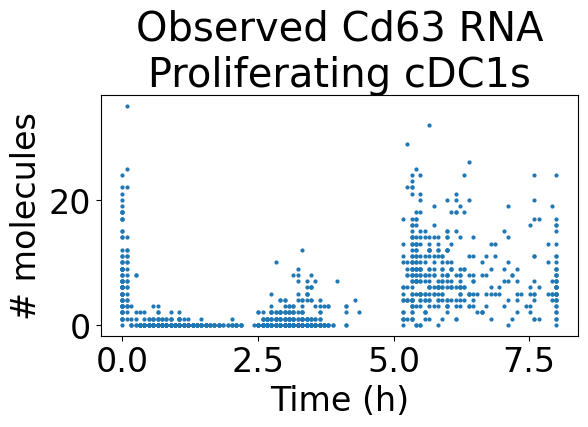

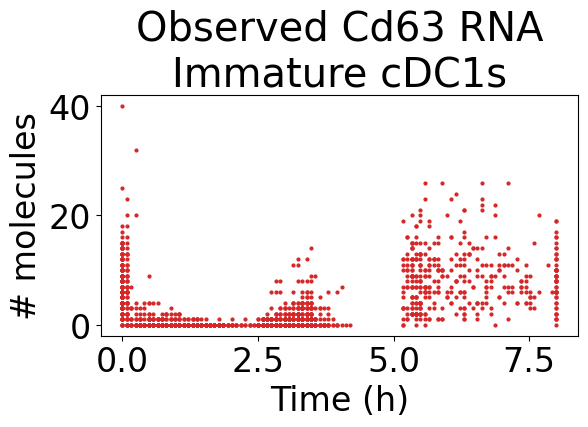

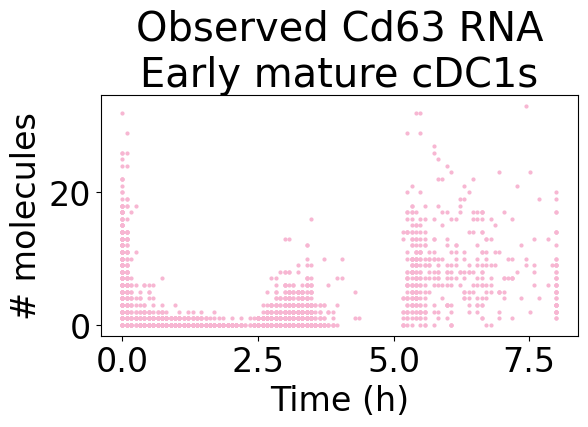

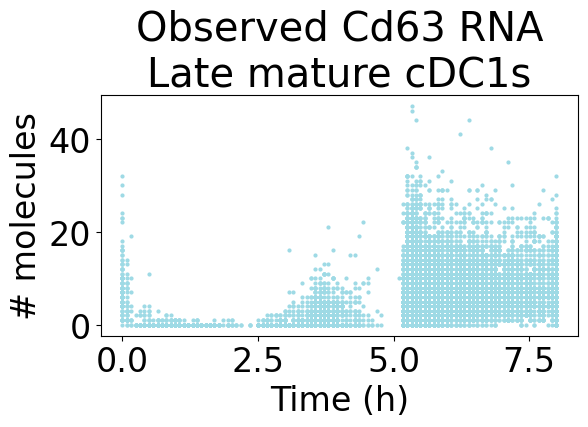

In [67]:
import matplotlib.pyplot as plt
import pandas as pd

clusters = pd.Categorical(sampleinfo["newClustersTmp"])
labels = list(clusters.categories)

# fixed color per cluster (consistent across all plots)
cmap = plt.get_cmap("tab20", len(labels))
color_for = {lbl: cmap(i) for i, lbl in enumerate(labels)}

x = t_per_cell
y = expr_RNA_ordered[gene]

for lbl in labels:
    mask = (clusters == lbl)

    plt.figure()
    plt.scatter(
        x[mask],
        y[mask],
        s=4,
        color=color_for[lbl]
    )
    plt.title(f"Observed {gene} RNA\n{lbl}")
    plt.xlabel("Time (h)")
    plt.ylabel("# molecules")
    plt.tight_layout()
    plt.show()


## Observed vs. imputed RNA

/tmp/ipykernel_2832107/403219594.py:6: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


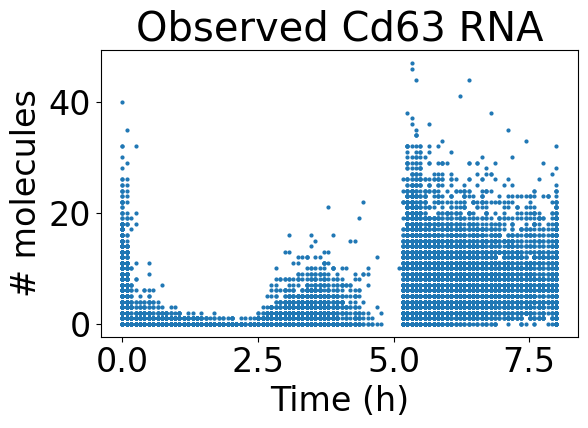

In [71]:
# --- RNA ---
plt.scatter(t_per_cell, expr_RNA_ordered[gene], s=4)
plt.title(f"Observed {gene} RNA")
plt.xlabel("Time (h)")
plt.ylabel("# molecules")
plt.tight_layout()
plt.show()

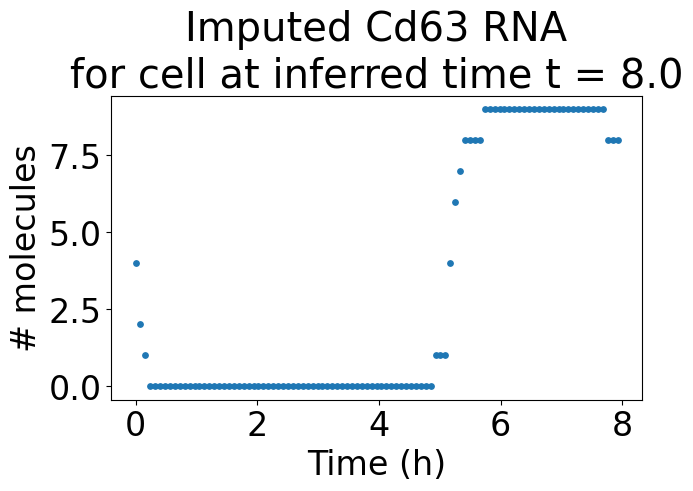

/tmp/ipykernel_2832107/428507315.py:14: UserWarning: The figure layout has changed to tight
  plt.tight_layout();


<Figure size 640x480 with 0 Axes>

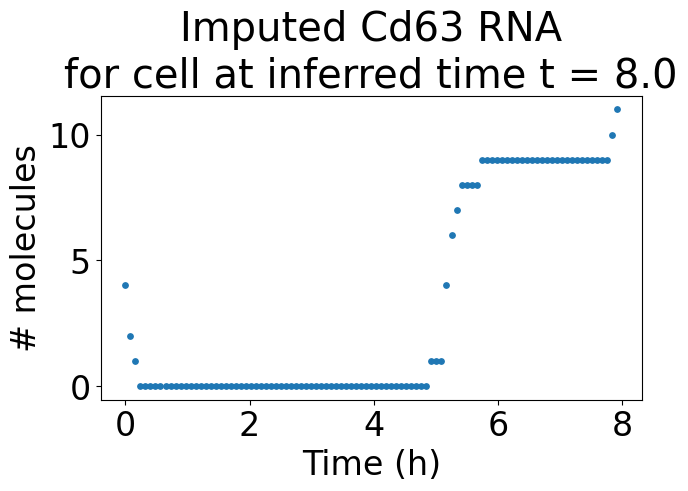

<Figure size 640x480 with 0 Axes>

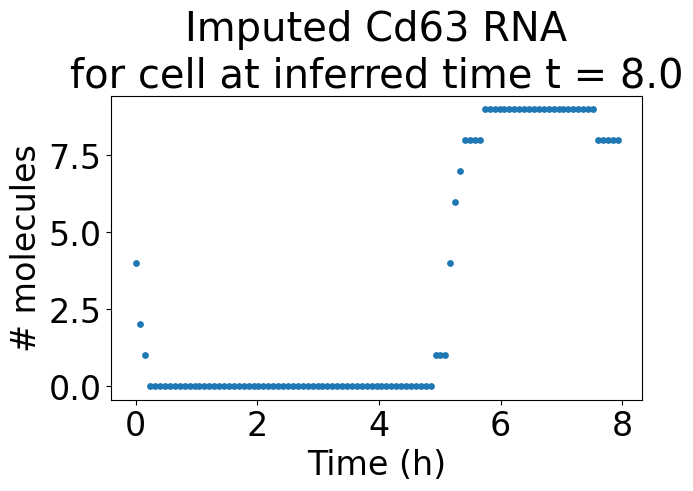

<Figure size 640x480 with 0 Axes>

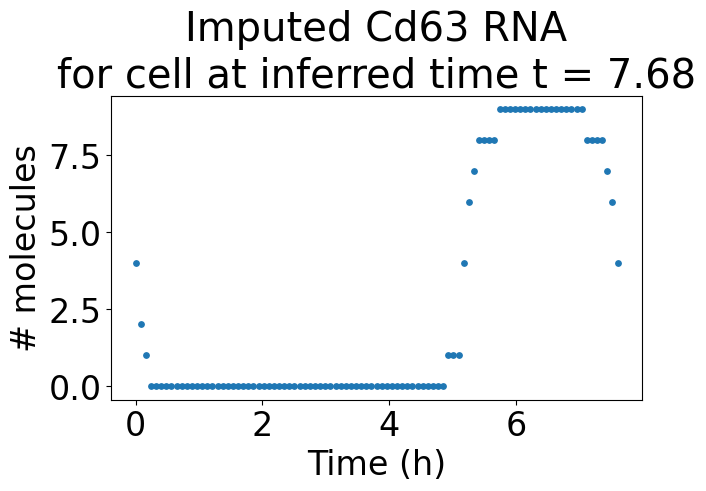

<Figure size 640x480 with 0 Axes>

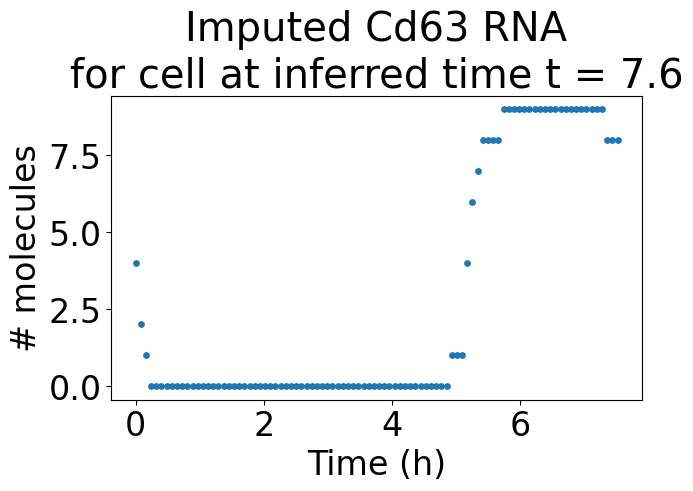

<Figure size 640x480 with 0 Axes>

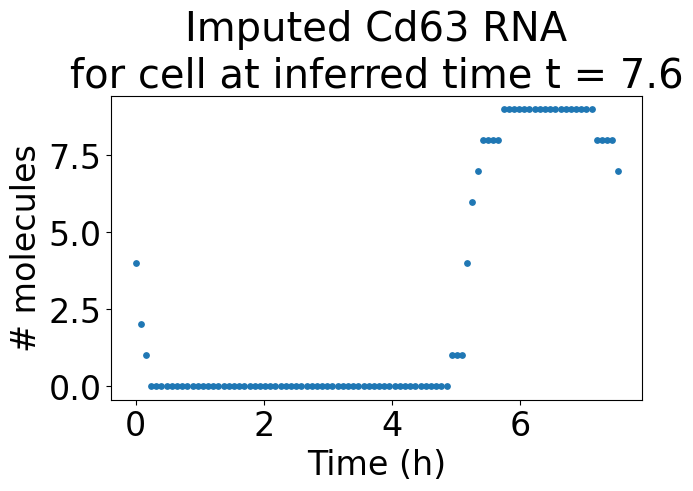

<Figure size 640x480 with 0 Axes>

In [72]:
for idx in (-1, -222, -1000, -1400, -1500, -1501):
    # idx = -92 # expr_ADT_imputed_ordered.loc[:, gene].argmax()
    plt.figure();
    start_idx = np.where(X_bw_ordered[idx, :] > -1)[0][-1]
    plt.scatter(
        t[:start_idx],
        X_bw_ordered[idx, :start_idx],
        s=15
    )
    plt.xlabel("Time (h)")
    plt.ylabel("# molecules")
    plt.title(f"Imputed {gene} RNA\nfor cell at inferred time t = {np.round(t_per_cell[idx], 2)}")
    plt.show();
    plt.tight_layout();
    

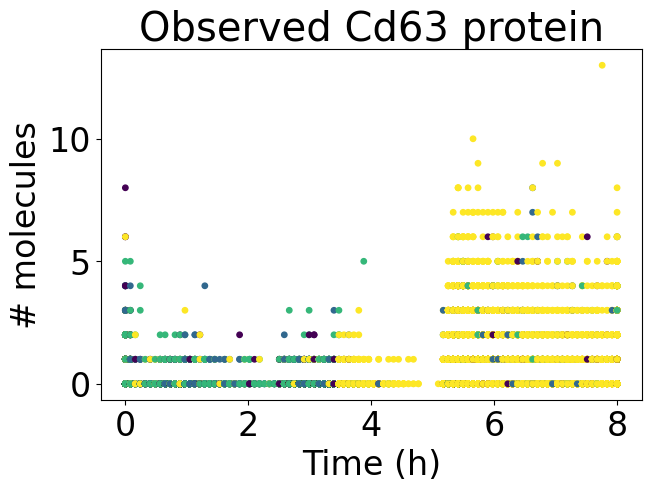

In [73]:
plt.scatter(
    t_per_cell,
    expr_ADT_ordered[prot],
    c=pd.Categorical(sampleinfo["newClustersTmp"]).codes,
    s=15
)
plt.xlabel("Time (h)")
plt.ylabel("# molecules")
plt.title(f"Observed {gene} protein");

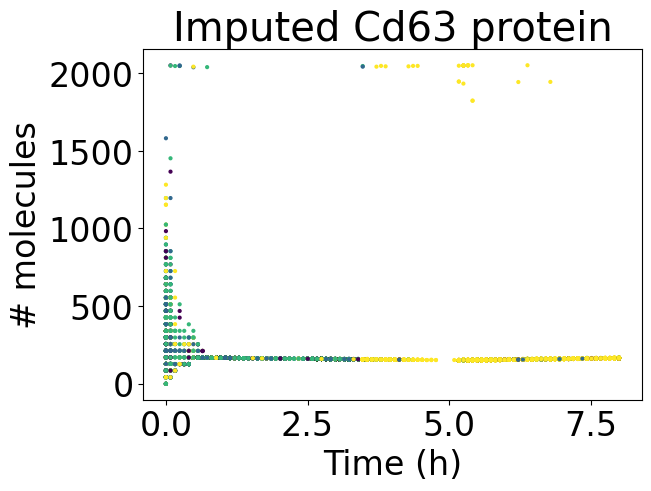

In [74]:
plt.scatter(
    t_per_cell,
    expr_ADT_imputed_ordered[gene],
    c=pd.Categorical(sampleinfo["newClustersTmp"]).codes,
    s=4
)
plt.xlabel("Time (h)")
plt.ylabel("# molecules")
plt.title(f"Imputed {gene} protein");

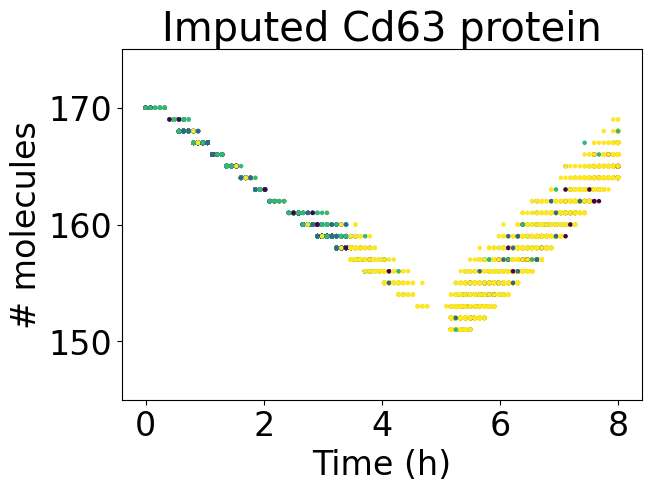

In [75]:
plt.scatter(
    t_per_cell,
    expr_ADT_imputed_ordered[gene],
    c=pd.Categorical(sampleinfo["newClustersTmp"]).codes,
    s=5
)
plt.xlabel("Time (h)")
plt.ylabel("# molecules")
plt.title(f"Imputed {gene} protein");
plt.ylim(145, 175)
plt.show()

# Double check my new protein imputation code is correct with simulated data

In [78]:
# Now let's try simulating protein using reconstructed RNA and kinetic parameters for the working gene

In [ ]:
tau = traj.tau # State transition times (global)
topo = traj.topo
true_t = traj.t
true_l = np.repeat(0, len(t)) 

# Get deg. rate for gene of interst

data_dir = "/mnt/lareaulab/reliscu/projects/Chronocell/data/experimental_parameters/protein_degradation_rates"
file_list = glob.glob(f"{data_dir}/*standardized.csv")
subset_columns = ['Gene', 'Half-life']

df_list = []
for file in [file for file in file_list if "Mouse" in file]:
    df = pd.read_csv(file)
    study = df['Study'].iloc[0]
    cell_type = df['Cell_type'].iloc[0]
    df = df[subset_columns]
    df = df.rename(columns={"Half-life": f"Half-life_{study}_{cell_type}", 
                            "Cell_type": f"Cell_type_{study}"}) 
    df_list.append(df)
    
df = reduce(lambda x, y: pd.merge(x, y, on="Gene", how="outer"), df_list)

half_life_cols = [col for col in df.columns if "Half-life" in col]
df_deg = np.log(2)/df[half_life_cols]
median_deg = np.nanmedian(df_deg, axis=1)

In [81]:
deg_rate = median_deg[np.where(df['Gene'] == gene)[0][0]]
deg_rate

np.float64(0.023397355708481997)

In [82]:
phi = np.zeros((1, 2))
phi[:,0] = 1
phi[:,-1] = deg_rate

In [ ]:
# Load imputed RNA for working gene (only spliced RNA was loaded above)

file_path = f"data/RNA_history_per_gene/{prefix}_{gene}_S_RNA_history.pkl"

with open(file_path, "rb") as f:
    X_bw_S = pickle.load(f)
    
file_path = f"data/RNA_history_per_gene/{prefix}_{gene}_U_RNA_history.pkl"

with open(file_path, "rb") as f:
    X_bw_U = pickle.load(f)

In [84]:
X_bw_S_ordered = X_bw_S[cell_order_idx, :]
X_bw_U_ordered = X_bw_U[cell_order_idx, :]

In [85]:
def simulate_protein_from_RNA(Y, topo, true_t, true_l, phi, step_size, random_seed=0):
    ## phi: Protein params
    np.random.seed(random_seed)
    
    L = len(topo) # No. lineages
    n = Y.shape[0] // L # No. cells per lineage
    p = Y.shape[1] # No. genes
    
    y0 = Y[0, :, 1] # RNA abundance per gene at state 0
    ss_rate = phi[:, 0] / phi[:, -1] # Steady-state protein production rate = transl_rate/deg_rate
    p0 = ss_rate * y0 # Initial protein abundance assuming steady-state
    print("y0:", y0)
   
    # Protein production paramters:
    transl_rates = phi[:, 0].T
    deg_rates = phi[:, -1].reshape((1, -1))
    
    P = np.zeros((n*L, p))
    
    for l in range(L):
        t_l = true_t[true_l == l] # Time points/cells in lineage l     
        dt = np.repeat(step_size, len(t_l)) # np.diff(t_l, prepend=-t_l[1]) # Time step size for each cell along the trajectory
        t_l = t_l.reshape((-1, 1)) 
        y_l = Y[l*n:(l+1)*n, :, 1] # Spliced RNAs for lineage l
        
        p_l = p0 * np.exp(-deg_rates * t_l) # Pre-existing protein that has not yet degraded
        print("p_old:", p_l[-1])
        
        t_diff = t_l - t_l.T # Rows = target time; columns = past times; e.g. t_diff[m, i] = time difference between t_m and t_i 
        decay_matrix = np.exp(-t_diff[:, :, None] * deg_rates) # Decay_matrix[m, i, p] = decay factor for protein abundance at t_m from RNA available at t_i for gene p
        mask = (t_diff >= 0)[:, :, None]
        mask = np.broadcast_to(mask, decay_matrix.shape)
        decay_matrix = np.where(mask, decay_matrix, 0) # Protein abundance at time t_m can't come from RNA at time t_i > t_m
        
        y_l_dt = y_l * dt[:, None] # Multiply each timepoint's RNA by its corresponding time step size (Riemann approximation)
        # Note to self: protein produced from RNA from time t = m can only be produced during the interval it was measured over, hence: scale RNA contribution at that time step by its time step size
        protein_contrib = (decay_matrix * y_l_dt[None, :, :]).sum(axis=1) # Integrate RNA counts still surviving up to each time point
        # Note to self: protein_contrib[target_idx, gene_idx] = np.sum(decay_matrix[target_time, :(target_time + 1), gene_idx] * y_l_dt[None, :(target_time + 1), gene_idx])
        P[l*n:(l+1)*n] = p_l + transl_rates * protein_contrib # Protein abundance in each cell = pre-existing protein + newly synthesized protein
        print("p_new:", (transl_rates * protein_contrib)[-1])
        print("P:", P[l*n:(l+1)*n][-1])
         
    P_observed = np.random.poisson(P)
        
    return P_observed, P, y0

In [86]:
step_size = t[1] - t[0]

In [ ]:
subset_idx = np.where(t_per_cell <= 8)[0]
P_curr = []
y0_imputed = []

for idx in subset_idx:
    print("===============")
    t_idx = np.where(true_t == t_per_cell[idx])[0][0]
    print("Inferfed t:", t[t_idx])
    
    u = X_bw_U_ordered[idx, :t_idx] if t_idx > 0 else X_bw_U_ordered[idx, :1]
    s = X_bw_S_ordered[idx, :t_idx] if t_idx > 0 else X_bw_S_ordered[idx, :1]
    
    if t_idx == 0:
        tt, tl = true_t[t_idx], true_l[t_idx]
    else:
        tt, tl = true_t[:t_idx], true_l[:t_idx]
        
    Y = np.empty((u.shape[0], 1, 2))
    Y[:, :, 0] = u[:, None]
    Y[:, :, 1] = s[:, None]
    
    P_observed, P, y0 = simulate_protein_from_RNA(Y, topo, tt, tl, phi, step_size, random_seed=0);
    
    P_curr.append(P[-1, :][0])
    y0_imputed.append(y0[0])

Inferfed t: 0.0
y0: [2.]
p_old: [85.47974502]
p_new: [0.16161616]
P: [85.64136118]
Inferfed t: 0.0
y0: [7.]
p_old: [299.17910755]
p_new: [0.56565657]
P: [299.74476412]
Inferfed t: 0.0
y0: [11.]
p_old: [470.13859759]
p_new: [0.88888889]
P: [471.02748647]
Inferfed t: 0.0
y0: [5.]
p_old: [213.69936254]
p_new: [0.4040404]
P: [214.10340294]
Inferfed t: 0.0
y0: [9.]
p_old: [384.65885257]
p_new: [0.72727273]
P: [385.3861253]
Inferfed t: 0.0
y0: [9.]
p_old: [384.65885257]
p_new: [0.72727273]
P: [385.3861253]
Inferfed t: 0.0
y0: [2.]
p_old: [85.47974502]
p_new: [0.16161616]
P: [85.64136118]
Inferfed t: 0.0
y0: [6.]
p_old: [256.43923505]
p_new: [0.48484848]
P: [256.92408353]
Inferfed t: 0.0
y0: [3.]
p_old: [128.21961752]
p_new: [0.24242424]
P: [128.46204177]
Inferfed t: 0.0
y0: [11.]
p_old: [470.13859759]
p_new: [0.88888889]
P: [471.02748647]
Inferfed t: 0.0
y0: [3.]
p_old: [128.21961752]
p_new: [0.24242424]
P: [128.46204177]
Inferfed t: 0.0
y0: [5.]
p_old: [213.69936254]
p_new: [0.4040404]
P: [

In [90]:
expr_ADT_imputed_ordered[gene].iloc[subset_idx]

Cell_ID
AGATAGACAAGGAGTC-2     85
CTCCGATCACGCGTCA-2    299
TCACACCAGGGTCTTT-2    470
CTCTCAGTCCCAACTC-2    213
CTGCAGGCAAGACGAC-2    384
                     ... 
TTACCATGTTGTAGCT-2    165
TCCGTGTGTTCCTACC-2    167
ATTCTTGTCCAAATGC-2    165
CATGCGGTCATTATCC-2    167
CATGAGTTCCGTATGA-2    166
Name: Cd63, Length: 21325, dtype: int64

In [91]:
np.corrcoef(expr_ADT_imputed_ordered[gene].iloc[subset_idx], P_curr)

array([[1.        , 0.99998508],
       [0.99998508, 1.        ]])

## Almost identitical. Which means that imputation code is working fine.

# I'm wondering: why are the protein estimates so high for cells at early time points, but considerably lower for cells at later time points? 

In [99]:
subset_idx = np.where(t_per_cell <= 0.3)[0]
P_curr = []
y0_imputed = []

for idx in subset_idx:
    print("===============")
    t_idx = np.where(true_t == t_per_cell[idx])[0][0]
    print("Inferfed t:", t[t_idx])
    
    u = X_bw_U_ordered[idx, :t_idx] if t_idx > 0 else X_bw_U_ordered[idx, :1]
    s = X_bw_S_ordered[idx, :t_idx] if t_idx > 0 else X_bw_S_ordered[idx, :1]
    
    if t_idx == 0:
        tt, tl = true_t[t_idx], true_l[t_idx]
    else:
        tt, tl = true_t[:t_idx], true_l[:t_idx]
        
    Y = np.empty((u.shape[0], 1, 2))
    Y[:, :, 0] = u[:, None]
    Y[:, :, 1] = s[:, None]
    
    P_observed, P, y0 = simulate_protein_from_RNA(Y, topo, tt, tl, phi, step_size, random_seed=0);
    
    P_curr.append(P[-1, :][0])
    y0_imputed.append(y0[0])

Inferfed t: 0.0
y0: [2.]
p_old: [85.47974502]
p_new: [0.16161616]
P: [85.64136118]
Inferfed t: 0.0
y0: [7.]
p_old: [299.17910755]
p_new: [0.56565657]
P: [299.74476412]
Inferfed t: 0.0
y0: [11.]
p_old: [470.13859759]
p_new: [0.88888889]
P: [471.02748647]
Inferfed t: 0.0
y0: [5.]
p_old: [213.69936254]
p_new: [0.4040404]
P: [214.10340294]
Inferfed t: 0.0
y0: [9.]
p_old: [384.65885257]
p_new: [0.72727273]
P: [385.3861253]
Inferfed t: 0.0
y0: [9.]
p_old: [384.65885257]
p_new: [0.72727273]
P: [385.3861253]
Inferfed t: 0.0
y0: [2.]
p_old: [85.47974502]
p_new: [0.16161616]
P: [85.64136118]
Inferfed t: 0.0
y0: [6.]
p_old: [256.43923505]
p_new: [0.48484848]
P: [256.92408353]
Inferfed t: 0.0
y0: [3.]
p_old: [128.21961752]
p_new: [0.24242424]
P: [128.46204177]
Inferfed t: 0.0
y0: [11.]
p_old: [470.13859759]
p_new: [0.88888889]
P: [471.02748647]
Inferfed t: 0.0
y0: [3.]
p_old: [128.21961752]
p_new: [0.24242424]
P: [128.46204177]
Inferfed t: 0.0
y0: [5.]
p_old: [213.69936254]
p_new: [0.4040404]
P: [

/tmp/ipykernel_2832107/281193825.py:3: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


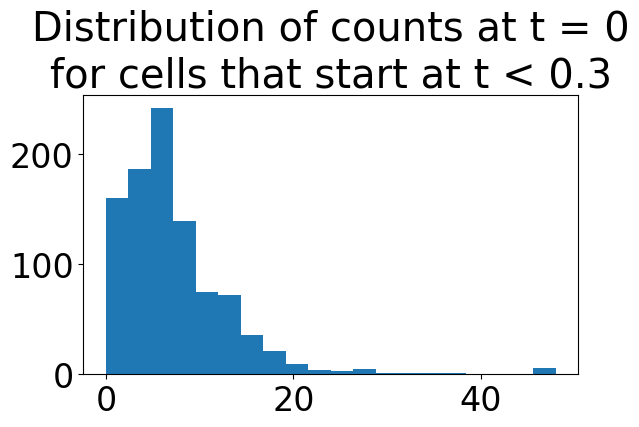

In [100]:
plt.hist(y0_imputed, bins=20);
plt.title("Distribution of counts at t = 0\nfor cells that start at t < 0.3");
plt.tight_layout()

In [94]:
subset_idx = np.where(t_per_cell > 6)[0]
P_curr = []
y0_imputed = []

for idx in subset_idx:
    print("===============")
    t_idx = np.where(true_t == t_per_cell[idx])[0][0]
    print("Inferfed t:", t[t_idx])
    
    u = X_bw_U_ordered[idx, :t_idx] if t_idx > 0 else X_bw_U_ordered[idx, :1]
    s = X_bw_S_ordered[idx, :t_idx] if t_idx > 0 else X_bw_S_ordered[idx, :1]
    
    if t_idx == 0:
        tt, tl = true_t[t_idx], true_l[t_idx]
    else:
        tt, tl = true_t[:t_idx], true_l[:t_idx]
        
    Y = np.empty((u.shape[0], 1, 2))
    Y[:, :, 0] = u[:, None]
    Y[:, :, 1] = s[:, None]
    
    P_observed, P, y0 = simulate_protein_from_RNA(Y, topo, tt, tl, phi, step_size, random_seed=0);
    
    P_curr.append(P[-1, :][0])
    y0_imputed.append(y0[0])

Inferfed t: 6.94949494949495
y0: [4.]
p_old: [145.57879961]
p_new: [15.30997311]
P: [160.88877273]
Inferfed t: 6.94949494949495
y0: [4.]
p_old: [145.57879961]
p_new: [15.55224472]
P: [161.13104433]
Inferfed t: 6.94949494949495
y0: [4.]
p_old: [145.57879961]
p_new: [14.58513685]
P: [160.16393647]
Inferfed t: 6.94949494949495
y0: [4.]
p_old: [145.57879961]
p_new: [14.58513685]
P: [160.16393647]
Inferfed t: 6.94949494949495
y0: [4.]
p_old: [145.57879961]
p_new: [15.39078119]
P: [160.96958081]
Inferfed t: 6.94949494949495
y0: [4.]
p_old: [145.57879961]
p_new: [15.71355589]
P: [161.2923555]
Inferfed t: 6.94949494949495
y0: [4.]
p_old: [145.57879961]
p_new: [14.90745622]
P: [160.48625583]
Inferfed t: 6.94949494949495
y0: [4.]
p_old: [145.57879961]
p_new: [15.0680065]
P: [160.64680611]
Inferfed t: 6.94949494949495
y0: [4.]
p_old: [145.57879961]
p_new: [14.58513685]
P: [160.16393647]
Inferfed t: 6.94949494949495
y0: [4.]
p_old: [145.57879961]
p_new: [14.90745622]
P: [160.48625583]
Inferfed t: 

/tmp/ipykernel_2832107/3610259589.py:3: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


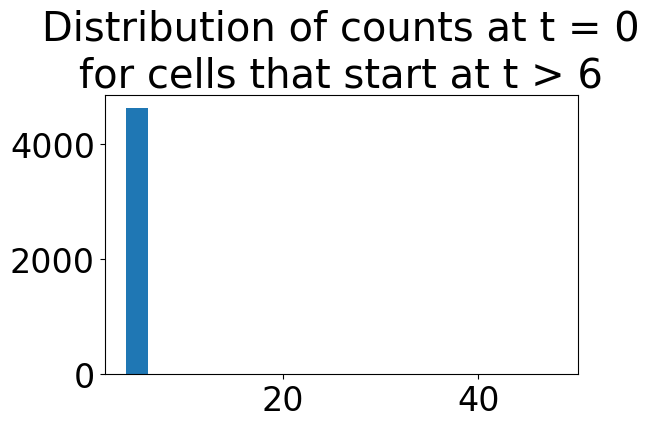

In [96]:
plt.hist(y0_imputed, bins=20);
plt.title("Distribution of counts at t = 0\nfor cells that start at t > 6");
plt.tight_layout()

### It looks like the issue is that cells from later in the trajectory all have RNA abundances that are the same since they revert to the mean by that point. Cells earlier in the trajectory still retain some variability, so many more cells have larger starting RNA abundances, hence higher imputed protein levels